## DBSCAN Clustering


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')
from sklearn.cluster import DBSCAN



In [57]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual_Income(k$),Spending_Score(1-100)
0,1,Male,49,123,51
1,2,Female,56,65,86
2,3,Male,66,68,57
3,4,Male,69,22,29
4,5,Male,49,41,78


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CustomerID             200 non-null    int64 
 1   Gender                 200 non-null    object
 2   Age                    200 non-null    int64 
 3   Annual_Income(k$)      200 non-null    int64 
 4   Spending_Score(1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [59]:
df.describe()

,CustomerID,Age,Annual_Income(k$),Spending_Score(1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,44.455000,77.075000,51.150000
std,57.879185,15.426205,36.604492,29.807886
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,32.750000,44.000000,24.000000
50%,100.500000,46.000000,74.000000,50.000000
75%,150.250000,56.000000,111.000000,76.500000
max,200.000000,70.000000,139.000000,100.000000


In [60]:
df.drop(columns=['CustomerID','Gender','Age'],  inplace=True)

In [61]:
df.head()

,Annual_Income(k$),Spending_Score(1-100)
0,123,51
1,65,86
2,68,57
3,22,29
4,41,78


In [62]:
df.rename(columns={'Annual_Income(k$)':'income',
          'Spending_Score(1-100)':'score'}, inplace=True)

df.head()

,income,score
0,123,51
1,65,86
2,68,57
3,22,29
4,41,78


In [63]:
for r in range(1, 10):
    for m in range(3,10):
        dbs = DBSCAN(eps = r, min_samples=m)
        df['db_cluster'] = dbs.fit_predict(df)

    if df['db_cluster'].nunique()==5:
        break

print('eps:',r)
print('min:',m)

eps: 9
min: 9


In [64]:
df['db_cluster'].unique()

array([-1,  2,  4,  0,  1,  3])

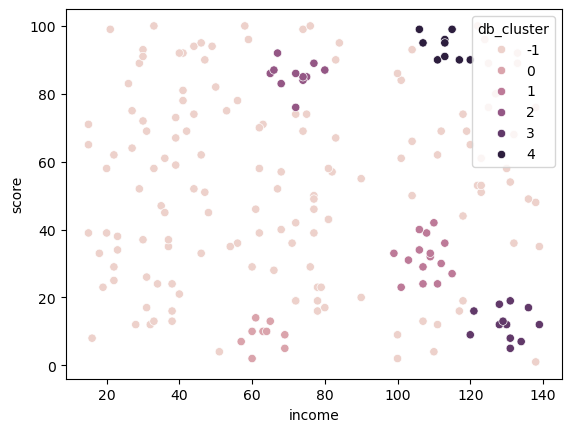

In [65]:
sns.scatterplot(x='income',y='score',hue='db_cluster',data=df)
plt.show()

##### In One Code

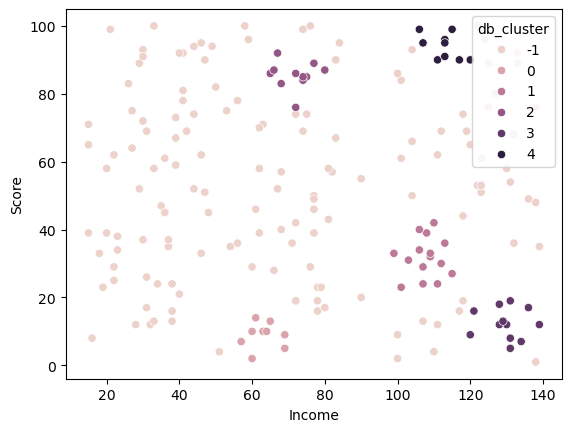

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

df = pd.read_csv('Mall_Customers.csv')
df.drop(columns=['CustomerID', 'Gender', 'Age'], inplace = True)  # its not a important
df.rename(columns= {
    'Annual_Income(k$)':'Income',
    'Spending_Score(1-100)':'Score'
}, inplace=True)

for r in range(1, 10):
    for m in range(3, 10):
        dbs = DBSCAN(eps= r, min_samples=m)
        df['db_cluster'] = dbs.fit_predict(df)
    if df['db_cluster'].nunique()==5:
        break

sns.scatterplot( x = 'Income', y ='Score', hue = 'db_cluster', data= df)
plt.show()
